In [1]:
import torch
from tqdm import tqdm
from torchinfo import summary
import matplotlib.pyplot as plt
import data_proc.data_preproc as data_preproc
import dino.dino_features as features

In [2]:
print(torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("compiled with cuda:", torch.backends.cuda.is_built())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

2.8.0+cu126
cuda available: True
torch cuda version: 12.6
compiled with cuda: True
device: cuda


# Data

In [3]:
img_net_loader, img_net_loader_val = data_preproc.tiny_image_net_dataloaders()

cuda


In [4]:
eruo_sat_loader, eruo_sat_loader_val = data_preproc.eurosat_rgb_dataloaders()

torch.Size([64, 3, 224, 224])


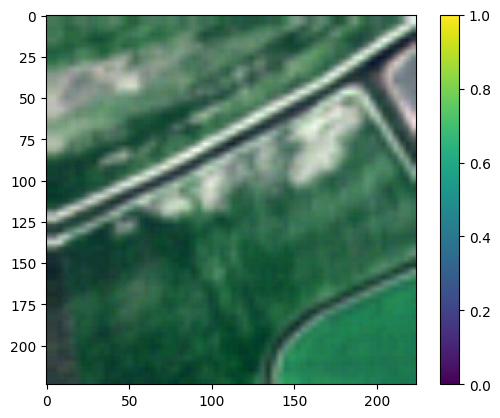

In [7]:
for batch in eruo_sat_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break


torch.Size([64, 3, 224, 224])


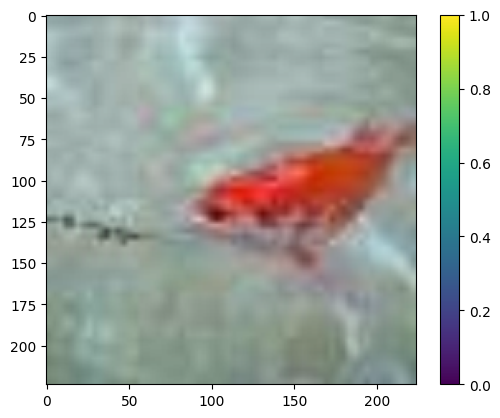

In [8]:
for batch in img_net_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break

# Features

In [ ]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
model.eval()
model.to("cuda")

In [ ]:
subsample_percent = 10
model.eval().to(device)

X_tiny_image_net, y_tiny_image_net = features.frozen_features(model, img_net_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_tiny_image_net, y_val_tiny_image_net = features.frozen_features(model, img_net_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

In [ ]:
subsample_percent = 10
model.eval().to(device)

X_eruosat_rgb, y_eruosat_rgb = features.frozen_features(model, eruo_sat_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_eruosat_rgb, y_val_eruosat_rgb = features.frozen_features(model, eruo_sat_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

# Zero Shot

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

def knn_score(X, y, X_val, y_val, k=5):
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X, y)

    neigh.score(X_val, y_val)

In [ ]:
knn_score(X_tiny_image_net, y_tiny_image_net, X_val_tiny_image_net, y_val_tiny_image_net, k=5)

In [ ]:
knn_score(X_eruosat_rgb, y_eruosat_rgb, X_val_eruosat_rgb, y_val_eruosat_rgb, k=5)